# AI Zero to Hero: Introduction to Google Colab

This practical converts the slide material into a guided, executable Colab notebook.

## Learning outcomes
- Create, rename and save a Colab notebook.
- Connect Google Drive and create course folders.
- Load and save CSV and Excel files.
- Use code cells, text cells, variables and packages.
- Complete a small analysis using `mtcars`.
- Save a modified dataset and a figure.

> Suggested filename: `AI_Zero_To_Hero_Session_1_1.ipynb`


## 1. Colab basics

Open `colab.research.google.com`, sign in, and choose **File > New notebook**.

- **Code cells** contain executable Python.
- **Text cells** contain Markdown headings, explanations and notes.
- Run a cell with the play button or **Shift+Enter**.


## 2. Connect Google Drive
Run this cell in Colab and approve the access request.


In [3]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print('Open this notebook in Google Colab to mount Drive.')


Mounted at /content/drive


## 3. Create the course folder structure
Google Drive is normally mounted at `/content/drive/MyDrive/`.


In [ ]:
from pathlib import Path
course_folder = Path('/content/drive/MyDrive/AI_Zero_To_Hero/AI_Zero_To_Hero_Shortcourse/')
data_folder = course_folder / 'Data'
notebooks_folder = course_folder / 'Notebooks'
figures_folder = course_folder / 'Figures'
for folder in [course_folder, data_folder, notebooks_folder, figures_folder]:
    folder.mkdir(parents=True, exist_ok=True)
print('Course folder:', course_folder)

Course folder: /content/drive/MyDrive/AI_Zero_To_Hero/AI_Zero_To_Hero_Shortcourse2


### View your Drive folders
Your own folder names will differ.


In [ ]:
my_drive = Path('/content/drive/MyDrive/')
print([item.name for item in my_drive.iterdir()] if my_drive.exists() else 'Mount Drive first.')


['BookShaddickZidek_workprogress', 'Yi', 'Colab Notebooks', 'Turing20_PostCOP26.docx', 'IMG_4019.jpg', 'Energizer - Day 1 PM.pptx', '6, THE RIDGEWAY, CRUDWELL  --  VAT INVOICE.gdoc', 'Session1_7_Python_Colab.ipynb', 'AI_Zero_To_Hero', 'InteractiveSheet_2026-09-28_12_11_20.gsheet']


## 4. Your first code cell


In [ ]:
print('Hello AI Zero To Hero')


Hello AI Zero To Hero


### Try it
Edit the message in the next cell and run it again.


In [ ]:
print('Edit this message')


Edit this message


## 5. Practise Markdown
Insert a text cell and enter:

```markdown
# My notes
I have learned how to use code and text cells.
- First point
- Second point
```


## 6. Variables and calculations


In [ ]:
course = 'AI Zero To Hero'
year = 2026
print(course)
print(year)


AI Zero To Hero
2026


In [ ]:
x = 10
y = 4
print('Addition:', x + y)
print('Subtraction:', x - y)
print('Multiplication:', x * y)
print('Division:', x / y)


Addition: 14
Subtraction: 6
Multiplication: 40
Division: 2.5


### Run cells in order
The second cell depends on a variable created in the first.


In [ ]:
hours = 6


In [ ]:
mark = 40 + 5 * hours
print(mark)


70


## 7. Import packages
`pandas` handles data tables, `matplotlib` creates figures, and `numpy` supports numerical operations.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print('Packages loaded')


Packages loaded


## 8. Loading files from Drive
These examples run only when the named files exist.


In [8]:
csv_file = data_folder / 'drugcosts.csv'
if csv_file.exists():
    drugcosts = pd.read_csv(csv_file)
    display(drugcosts.head())
else:
    print('File not found:', csv_file)


NameError: name 'data_folder' is not defined

In [ ]:
excel_file = data_folder / 'drugcosts.xlsx'
if excel_file.exists():
    drugcosts_excel = pd.read_excel(excel_file)
    display(drugcosts_excel.head())
else:
    print('File not found:', excel_file)


,CostOfDrug
0,2.0
1,4.0
2,6.2
3,8.0
4,8.0


In [ ]:
print('Files in data_folder:')
for item in data_folder.iterdir():
    if item.is_file():
        print(item.name)

Files in data_folder:
updated_costs2.csv
drugcosts.csv
drugcosts.xlsx
wnv.csv
updated_costs.csv
mtcars.csv
iris.csv


In [ ]:
print(data_folder)

/content/drive/MyDrive/AI_Zero_To_Hero/AI_Zero_To_Hero_Shortcourse2/Data


### Create and save a category
If `drugcosts.csv` contains `CostOfDrug`, classify values above 100 as Expensive.


In [ ]:
if 'drugcosts' in globals() and 'CostOfDrug' in drugcosts.columns:
    drugcosts['Category'] = np.where(drugcosts['CostOfDrug'] > 100, 'Expensive', 'Standard')
    updated_file = data_folder / 'updated_costs.csv'
    drugcosts.to_csv(updated_file, index=False)
    print('Saved:', updated_file)
else:
    print('Load a file containing CostOfDrug first.')


Saved: /content/drive/MyDrive/AI_Zero_To_Hero/AI_Zero_To_Hero_Shortcourse2/Data/updated_costs.csv


# Complete example using `mtcars`

Variables:
- `mpg`: miles per gallon
- `wt`: weight in thousands of pounds
- `hp`: gross horsepower


## 9. Create the dataset


In [ ]:
mtcars = pd.DataFrame({
    'mpg': [21.0, 21.0, 22.8, 21.4, 18.7, 18.1, 14.3, 24.4],
    'wt': [2.620, 2.875, 2.320, 3.215, 3.440, 3.460, 3.570, 3.190],
    'hp': [110, 110, 93, 110, 175, 105, 245, 62]
})
mtcars


,mpg,wt,hp
0,21.0,2.620,110
1,21.0,2.875,110
2,22.8,2.320,93
3,21.4,3.215,110
4,18.7,3.440,175
5,18.1,3.460,105
6,14.3,3.570,245
7,24.4,3.190,62


In [ ]:
mtcars_data = pd.read_csv(data_folder / 'mtcars.csv')
mtcars_data.head()


,manufacturer,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=mtcars_data)

https://docs.google.com/spreadsheets/d/1ruJejYaZOXaXrXtyTtehuhiD54btGL4F3VvH0j7kgCE/edit#gid=0


## 10. Save and reload the dataset


In [ ]:
source_file = data_folder / 'mtcars.csv'
mtcars.to_csv(source_file, index=False)
print('Saved:', source_file)


Saved: /content/drive/MyDrive/AI_Zero_To_Hero/AI_Zero_To_Hero_Shortcourse2/Data/mtcars.csv


In [ ]:
mtcars_data = pd.read_csv(source_file)
mtcars_data.head()


,manufacturer,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


## 11. Explore the data


In [ ]:
print('Shape:', mtcars_data.shape)
print('Columns:', mtcars_data.columns.tolist())
mtcars_data.head()


Shape: (32, 12)
Columns: ['manufacturer', 'mpg', 'cyl', 'disp', 'hp', 'drat', 'wt', 'qsec', 'vs', 'am', 'gear', 'carb']


,manufacturer,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [ ]:
mtcars_data.describe()


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.0000
mean,20.090625,6.187500,230.721875,146.687500,3.596563,3.217250,17.848750,0.437500,0.406250,3.687500,2.8125
std,6.026948,1.785922,123.938694,68.562868,0.534679,0.978457,1.786943,0.504016,0.498991,0.737804,1.6152
min,10.400000,4.000000,71.100000,52.000000,2.760000,1.513000,14.500000,0.000000,0.000000,3.000000,1.0000
25%,15.425000,4.000000,120.825000,96.500000,3.080000,2.581250,16.892500,0.000000,0.000000,3.000000,2.0000
50%,19.200000,6.000000,196.300000,123.000000,3.695000,3.325000,17.710000,0.000000,0.000000,4.000000,2.0000
75%,22.800000,8.000000,326.000000,180.000000,3.920000,3.610000,18.900000,1.000000,1.000000,4.000000,4.0000
max,33.900000,8.000000,472.000000,335.000000,4.930000,5.424000,22.900000,1.000000,1.000000,5.000000,8.0000


Discuss: How many observations are present? What are the ranges of `mpg`, `wt` and `hp`?


## 12. Calculate average fuel consumption


In [ ]:
mean_mpg = mtcars_data['mpg'].mean()
print(f'Average fuel consumption: {mean_mpg:.4f} miles per gallon')


Average fuel consumption: 20.0906 miles per gallon


## 13. Find the highest-horsepower observation


In [ ]:
highest_hp_row = mtcars_data.loc[mtcars_data['hp'].idxmax()]
highest_hp_row


,30
manufacturer,Maserati Bora
mpg,15.0
cyl,8
disp,301.0
hp,335
drat,3.54
wt,3.57
qsec,14.6
vs,0
am,1


What `mpg` and `wt` values are associated with the highest horsepower?


## 14. Plot fuel consumption against weight


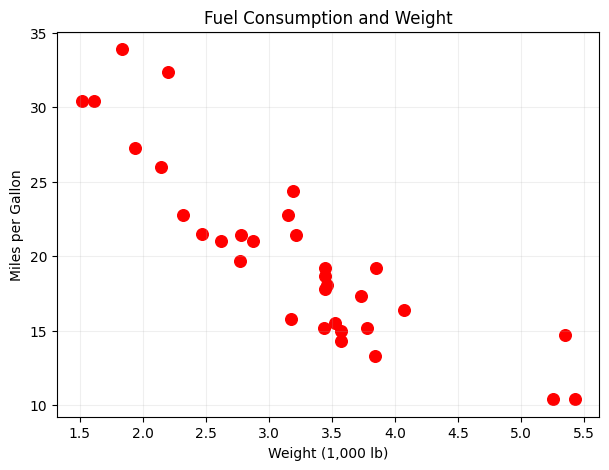

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(mtcars_data['wt'], mtcars_data['mpg'], color='red', s=70)
plt.xlabel('Weight (1,000 lb)')
plt.ylabel('Miles per Gallon')
plt.title('Fuel Consumption and Weight')
plt.grid(alpha=0.2)
plt.show()


Does fuel consumption appear to decrease as vehicle weight increases?


## 15. Create a vehicle size category
- Light: up to 2.8
- Medium: above 2.8 and up to 3.3
- Heavy: above 3.3


In [ ]:
mtcars_data['size'] = pd.cut(
    mtcars_data['wt'], bins=[0, 2.8, 3.3, float('inf')],
    labels=['Light', 'Medium', 'Heavy'], include_lowest=True
)
mtcars_data


,manufacturer,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,size
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4,Light
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4,Medium
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1,Light
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1,Medium
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2,Heavy
5,Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1,Heavy
6,Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4,Heavy
7,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2,Medium
8,Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2,Medium
9,Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4,Heavy


## 16. Save the modified dataset


In [ ]:
modified_file = data_folder / 'mtcars_modified.csv'
mtcars_data.to_csv(modified_file, index=False)
print('Saved:', modified_file)


Saved: /content/drive/MyDrive/AI_Zero_To_Hero/AI_Zero_To_Hero_Shortcourse2/Data/mtcars_modified.csv


## 17. Save the scatter plot


In [ ]:
figure_file = figures_folder / 'mtcars_scatterplot.png'
plt.figure(figsize=(7, 5))
plt.scatter(mtcars_data['wt'], mtcars_data['mpg'], color='red', s=70)
plt.xlabel('Weight (1,000 lb)')
plt.ylabel('Miles per Gallon')
plt.title('Fuel Consumption and Weight')
plt.grid(alpha=0.2)
plt.savefig(figure_file, dpi=300, bbox_inches='tight')
plt.show()
print('Saved:', figure_file)


## 18. Check the saved files


In [ ]:
print('Data files:', sorted(p.name for p in data_folder.glob('mtcars*')))
print('Figure files:', sorted(p.name for p in figures_folder.glob('mtcars*')))


# Exercise and questions

Complete the whole workflow, then add a text cell answering:
1. What is the average `mpg`?
2. Which observation has the highest `hp`?
3. Does `mpg` appear to decrease as weight increases?
4. Why is saving directly to Google Drive useful?
5. What is the difference between a code cell and a text cell?


# Summary
You have mounted Drive, created folders, used Markdown and Python cells, loaded and saved data, explored `mtcars`, created a variable, produced a graph, and saved the outputs.
